In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from io import StringIO
from prettytable import PrettyTable

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression, LinearRegression

In [2]:
df = pd.read_csv("penguins.csv")

print(df.head())

print(df.isnull().sum())

   CulmenLength  CulmenDepth  FlipperLength  BodyMass  Species
0          39.1         18.7          181.0    3750.0        0
1          39.5         17.4          186.0    3800.0        0
2          40.3         18.0          195.0    3250.0        0
3           NaN          NaN            NaN       NaN        0
4          36.7         19.3          193.0    3450.0        0
CulmenLength     2
CulmenDepth      2
FlipperLength    2
BodyMass         2
Species          0
dtype: int64


In [3]:
df = df.dropna()

print(df.head())
print(df.describe())

   CulmenLength  CulmenDepth  FlipperLength  BodyMass  Species
0          39.1         18.7          181.0    3750.0        0
1          39.5         17.4          186.0    3800.0        0
2          40.3         18.0          195.0    3250.0        0
4          36.7         19.3          193.0    3450.0        0
5          39.3         20.6          190.0    3650.0        0
       CulmenLength  CulmenDepth  FlipperLength     BodyMass     Species
count    342.000000   342.000000     342.000000   342.000000  342.000000
mean      43.921930    17.151170     200.915205  4201.754386    0.757310
std        5.459584     1.974793      14.061714   801.954536    0.763648
min       32.100000    13.100000     172.000000  2700.000000    0.000000
25%       39.225000    15.600000     190.000000  3550.000000    0.000000
50%       44.450000    17.300000     197.000000  4050.000000    1.000000
75%       48.500000    18.700000     213.000000  4750.000000    1.000000
max       59.600000    21.500000     2

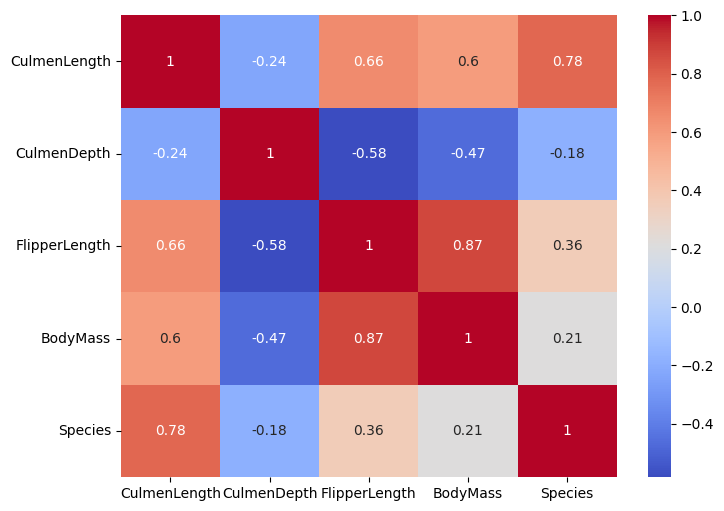

In [4]:
# Korelacje

plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [5]:
# Dane do klasyfikacji Species

X = df.drop("Species", axis=1)
y = df["Species"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# Fcja do pokazania wariancji wyjasnionej prze PCA

def show_pca_variance(pca_model, title):
    pca_variance = pd.DataFrame({
        "Skladowa": [f"PC{i+1}" for i in range(len(pca_model.explained_variance_ratio_))],
        "Wariancja wyjasniona": np.round(pca_model.explained_variance_ratio_, 4),
        "Wariancja wyjasniona [%]": np.round(pca_model.explained_variance_ratio_ * 100, 2),
        "Wariancja skumulowana [%]": np.round(np.cumsum(pca_model.explained_variance_ratio_) * 100,2)})

    print(f"\n{title}")
    print(pca_variance.to_string(index=False))

    return pca_variance

In [7]:
# PCA dla klasyfikacji

pca = PCA(random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

#wyswietlanie PCA
pca_variance_classification = show_pca_variance(
    pca,
    "PCA dla klasyfikacji - wariancja wyjasniana przez skladowe")

train_penguins = pd.DataFrame(
    X_train_pca,
    columns=[f"PC{i+1}" for i in range(X_train_pca.shape[1])])

train_penguins["Species"] = np.array(y_train).reshape(-1)

print("\nKorelacje po PCA:")
print(train_penguins.corr(numeric_only=True))


PCA dla klasyfikacji - wariancja wyjasniana przez skladowe
Skladowa  Wariancja wyjasniona  Wariancja wyjasniona [%]  Wariancja skumulowana [%]
     PC1                0.6873                     68.73                      68.73
     PC2                0.1936                     19.36                      88.09
     PC3                0.0912                      9.12                      97.20
     PC4                0.0280                      2.80                     100.00

Korelacje po PCA:
                  PC1           PC2           PC3           PC4   Species
PC1      1.000000e+00  5.686381e-17  2.266550e-16 -9.505995e-16  0.449861
PC2      5.686381e-17  1.000000e+00 -2.981033e-16  8.748870e-16  0.370574
PC3      2.266550e-16 -2.981033e-16  1.000000e+00  8.236942e-16  0.616517
PC4     -9.505995e-16  8.748870e-16  8.236942e-16  1.000000e+00  0.060144
Species  4.498607e-01  3.705740e-01  6.165168e-01  6.014422e-02  1.000000


In [8]:
#porownanie klasyfikacji

def train_and_check(Xtrain, Xtest, ytrain, ytest):
    classifier = LogisticRegression(max_iter=100000)

    start = time.perf_counter() #zamiast .microseconds
    classifier.fit(Xtrain, ytrain)
    end = time.perf_counter()

    training_time_microseconds = int(round((end - start) * 1_000_000))
    evaluation = np.round(classifier.score(Xtest, ytest), 4)

    return evaluation, training_time_microseconds

In [9]:
results = PrettyTable([
    'Model',
    'Dokladnosc',
    'Czas trenowania (microseconds)'])

not_scaled_data = train_and_check(X_train, X_test, y_train, y_test)
results.add_row(['Nieskalowane dane', not_scaled_data[0], not_scaled_data[1]])

scaled_data = train_and_check(X_train_scaled, X_test_scaled, y_train, y_test)
results.add_row(['Skalowane dane', scaled_data[0], scaled_data[1]])

for n_components in range(X_train_pca.shape[1], 0, -1):
    pc_data = train_and_check(
        X_train_pca[:, :n_components],
        X_test_pca[:, :n_components],
        y_train, y_test)

    results.add_row([
        f'{n_components} PC',
        pc_data[0],
        pc_data[1]])

print(results)

+-------------------+------------+--------------------------------+
|       Model       | Dokladnosc | Czas trenowania (microseconds) |
+-------------------+------------+--------------------------------+
| Nieskalowane dane |   0.9855   |             597461             |
|   Skalowane dane  |    1.0     |              3488              |
|        4 PC       |    1.0     |              3276              |
|        3 PC       |    1.0     |              3202              |
|        2 PC       |   0.942    |              3751              |
|        1 PC       |   0.9275   |              3952              |
+-------------------+------------+--------------------------------+


In [10]:
# PCA dla regresji

X_reg = df.drop('BodyMass', axis=1).copy()
y_reg = df['BodyMass'].copy()

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42)

numeric_features_reg = [
    column for column in X_reg.columns
    if column != "Species"]

categorical_features_reg = ["Species"]

#uzyce OnehotEncoder
try:
    one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False)
except TypeError:
    one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False)


preprocessor_reg = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features_reg),
        ("cat", one_hot_encoder, categorical_features_reg)])

X_train_reg_processed = preprocessor_reg.fit_transform(X_train_reg)
X_test_reg_processed = preprocessor_reg.transform(X_test_reg)

try:
    feature_names_reg = preprocessor_reg.get_feature_names_out()
except AttributeError:
    feature_names_reg = [
        *numeric_features_reg,
        *preprocessor_reg.named_transformers_["cat"].get_feature_names(categorical_features_reg)]

pca_reg = PCA(random_state=42)

X_train_reg_pca = pca_reg.fit_transform(X_train_reg_processed)
X_test_reg_pca = pca_reg.transform(X_test_reg_processed)

# pokazanie PCA w regresji
pca_variance_regression = show_pca_variance(
    pca_reg,
    "PCA dla regresji - wariancja wyjasniana przez skladowe")


PCA dla regresji - wariancja wyjasniana przez skladowe
Skladowa  Wariancja wyjasniona  Wariancja wyjasniona [%]  Wariancja skumulowana [%]
     PC1                0.6455                     64.55                      64.55
     PC2                0.2446                     24.46                      89.00
     PC3                0.0846                      8.46                      97.47
     PC4                0.0188                      1.88                      99.35
     PC5                0.0065                      0.65                     100.00
     PC6                0.0000                      0.00                     100.00


In [11]:
train_penguins_reg = pd.DataFrame(
    X_train_reg_pca,
    columns=[f"PC{i+1}" for i in range(X_train_reg_pca.shape[1])])

train_penguins_reg["BodyMass"] = np.array(y_train_reg).reshape(-1)

print("\nKorelacje po PCA dla regresji:")
print(train_penguins_reg.corr(numeric_only=True))


Korelacje po PCA dla regresji:
                   PC1           PC2           PC3           PC4  \
PC1       1.000000e+00 -2.213431e-16 -2.914336e-16  3.974770e-17   
PC2      -2.213431e-16  1.000000e+00 -4.163302e-16 -2.846900e-15   
PC3      -2.914336e-16 -4.163302e-16  1.000000e+00 -5.252315e-16   
PC4       3.974770e-17 -2.846900e-15 -5.252315e-16  1.000000e+00   
PC5      -1.143215e-15  1.220446e-16  1.675097e-15  2.254351e-15   
PC6      -1.620450e-01  1.491893e-01 -3.169200e-02 -9.627926e-01   
BodyMass  8.031433e-01 -1.013928e-02  3.979810e-01 -1.438946e-01   

                   PC5       PC6  BodyMass  
PC1      -1.143215e-15 -0.162045  0.803143  
PC2       1.220446e-16  0.149189 -0.010139  
PC3       1.675097e-15 -0.031692  0.397981  
PC4       2.254351e-15 -0.962793 -0.143895  
PC5       1.000000e+00 -0.113978  0.161703  
PC6      -1.139784e-01  1.000000 -0.023262  
BodyMass  1.617027e-01 -0.023262  1.000000  


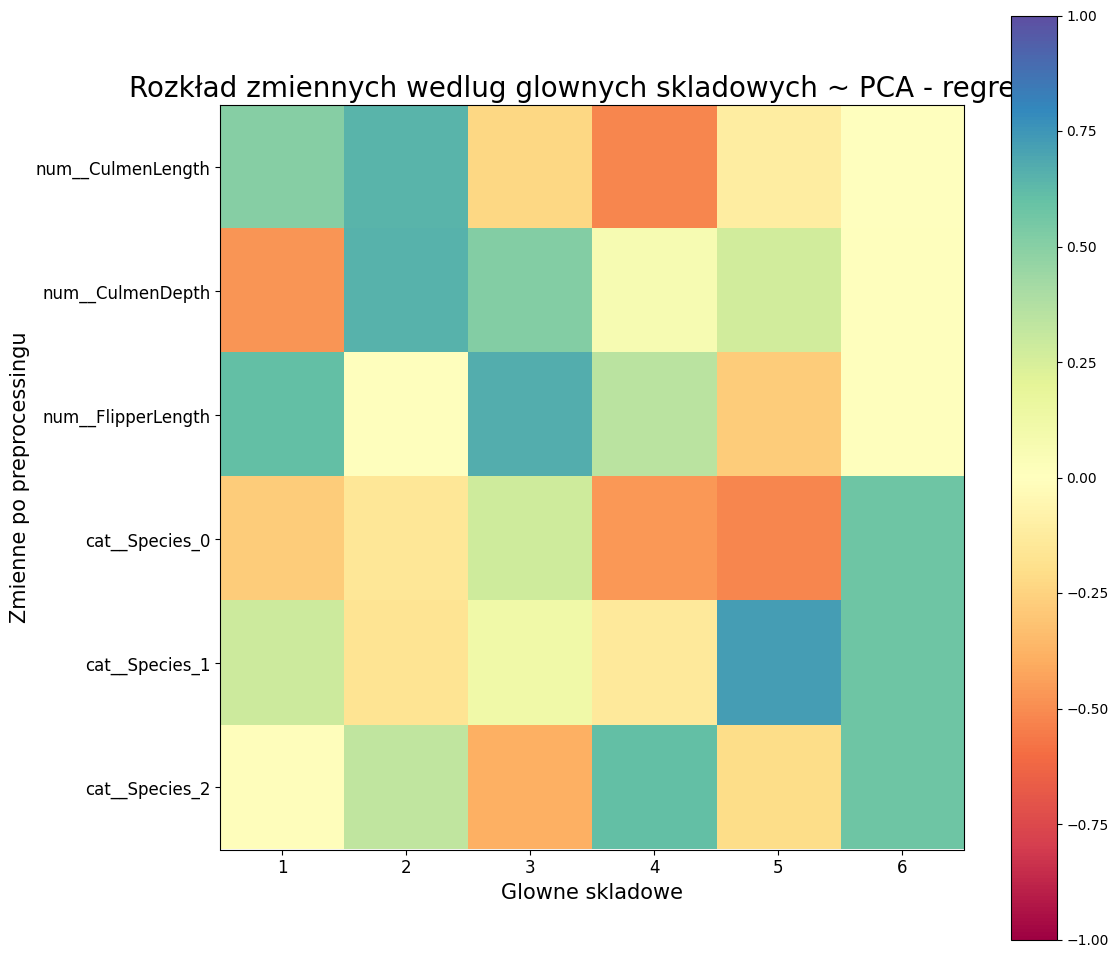

In [12]:
fig, ax = plt.subplots(figsize=(12, 12))

plt.imshow(
    pca_reg.components_.T,
    cmap='Spectral',
    vmin=-1,
    vmax=1)

plt.yticks(
    range(len(feature_names_reg)),
    feature_names_reg,
    fontsize=12)

plt.xticks(
    range(X_train_reg_pca.shape[1]),
    range(1, X_train_reg_pca.shape[1] + 1),
    fontsize=12)

plt.xlabel('Glowne skladowe', fontsize=15)
plt.ylabel('Zmienne po preprocessingu', fontsize=15)
plt.title(
    'Rozkład zmiennych wedlug glownych skladowych ~ PCA - regresja',
    fontsize=20)

plt.colorbar()
plt.show()

In [13]:
# porownanie regresji

def train_and_check_regression(Xtrain, Xtest, ytrain, ytest):
    model = LinearRegression()

    start = time.perf_counter()
    model.fit(Xtrain, ytrain)
    end = time.perf_counter()

    training_time_microseconds = int(round((end - start) * 1_000_000))
    evaluation = np.round(model.score(Xtest, ytest), 4)

    return evaluation, training_time_microseconds

In [14]:
results_reg = PrettyTable([
    'Model',
    'R2',
    'Czas trenowania (microseconds)'])

not_scaled_data = train_and_check_regression(
    X_train_reg,
    X_test_reg,
    y_train_reg,
    y_test_reg)
results_reg.add_row(['Nieskalowane dane', not_scaled_data[0], not_scaled_data[1]])

processed_data = train_and_check_regression(
    X_train_reg_processed,
    X_test_reg_processed,
    y_train_reg,
    y_test_reg)
results_reg.add_row(['Po preprocessingu', processed_data[0], processed_data[1]])

all_pc_data = train_and_check_regression(
    X_train_reg_pca,
    X_test_reg_pca,
    y_train_reg,
    y_test_reg)
results_reg.add_row([
    f'{X_train_reg_pca.shape[1]} PC - wszystkie',
    all_pc_data[0],
    all_pc_data[1]])

for n_components in range(min(4, X_train_reg_pca.shape[1]), 0, -1):
    pc_data = train_and_check_regression(
        X_train_reg_pca[:, :n_components],
        X_test_reg_pca[:, :n_components],
        y_train_reg,
        y_test_reg)

    results_reg.add_row([
        f'{n_components} PC',
        pc_data[0],
        pc_data[1]])

print(results_reg)

+-------------------+--------+--------------------------------+
|       Model       |   R2   | Czas trenowania (microseconds) |
+-------------------+--------+--------------------------------+
| Nieskalowane dane | 0.8228 |              3138              |
| Po preprocessingu | 0.8279 |              1085              |
|  6 PC - wszystkie | 0.8279 |              975               |
|        4 PC       | 0.8346 |              804               |
|        3 PC       | 0.817  |              1103              |
|        2 PC       | 0.6461 |              637               |
|        1 PC       | 0.6487 |              540               |
+-------------------+--------+--------------------------------+
